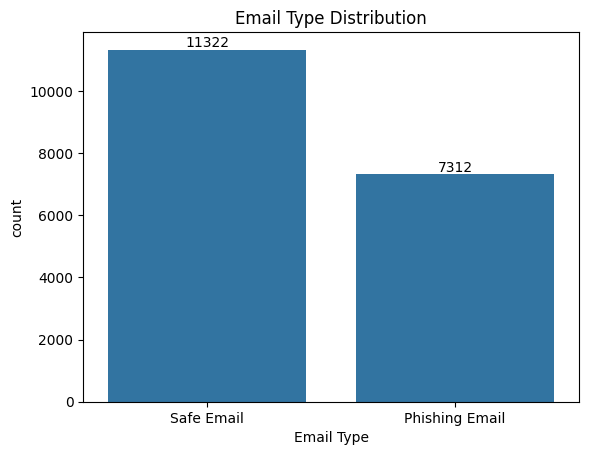

c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[LightGBM] [Info] Number of positive: 9113, number of negative: 5794
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.234618 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319127
[LightGBM] [Info] Number of data points in the train set: 14907, number of used features: 4876
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.611324 -> initscore=0.452879
[LightGBM] [Info] Start training from score 0.452879


c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[LightGBM] [Info] Number of positive: 9113, number of negative: 5794
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.249467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319127
[LightGBM] [Info] Number of data points in the train set: 14907, number of used features: 4876
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.611324 -> initscore=0.452879
[LightGBM] [Info] Start training from score 0.452879


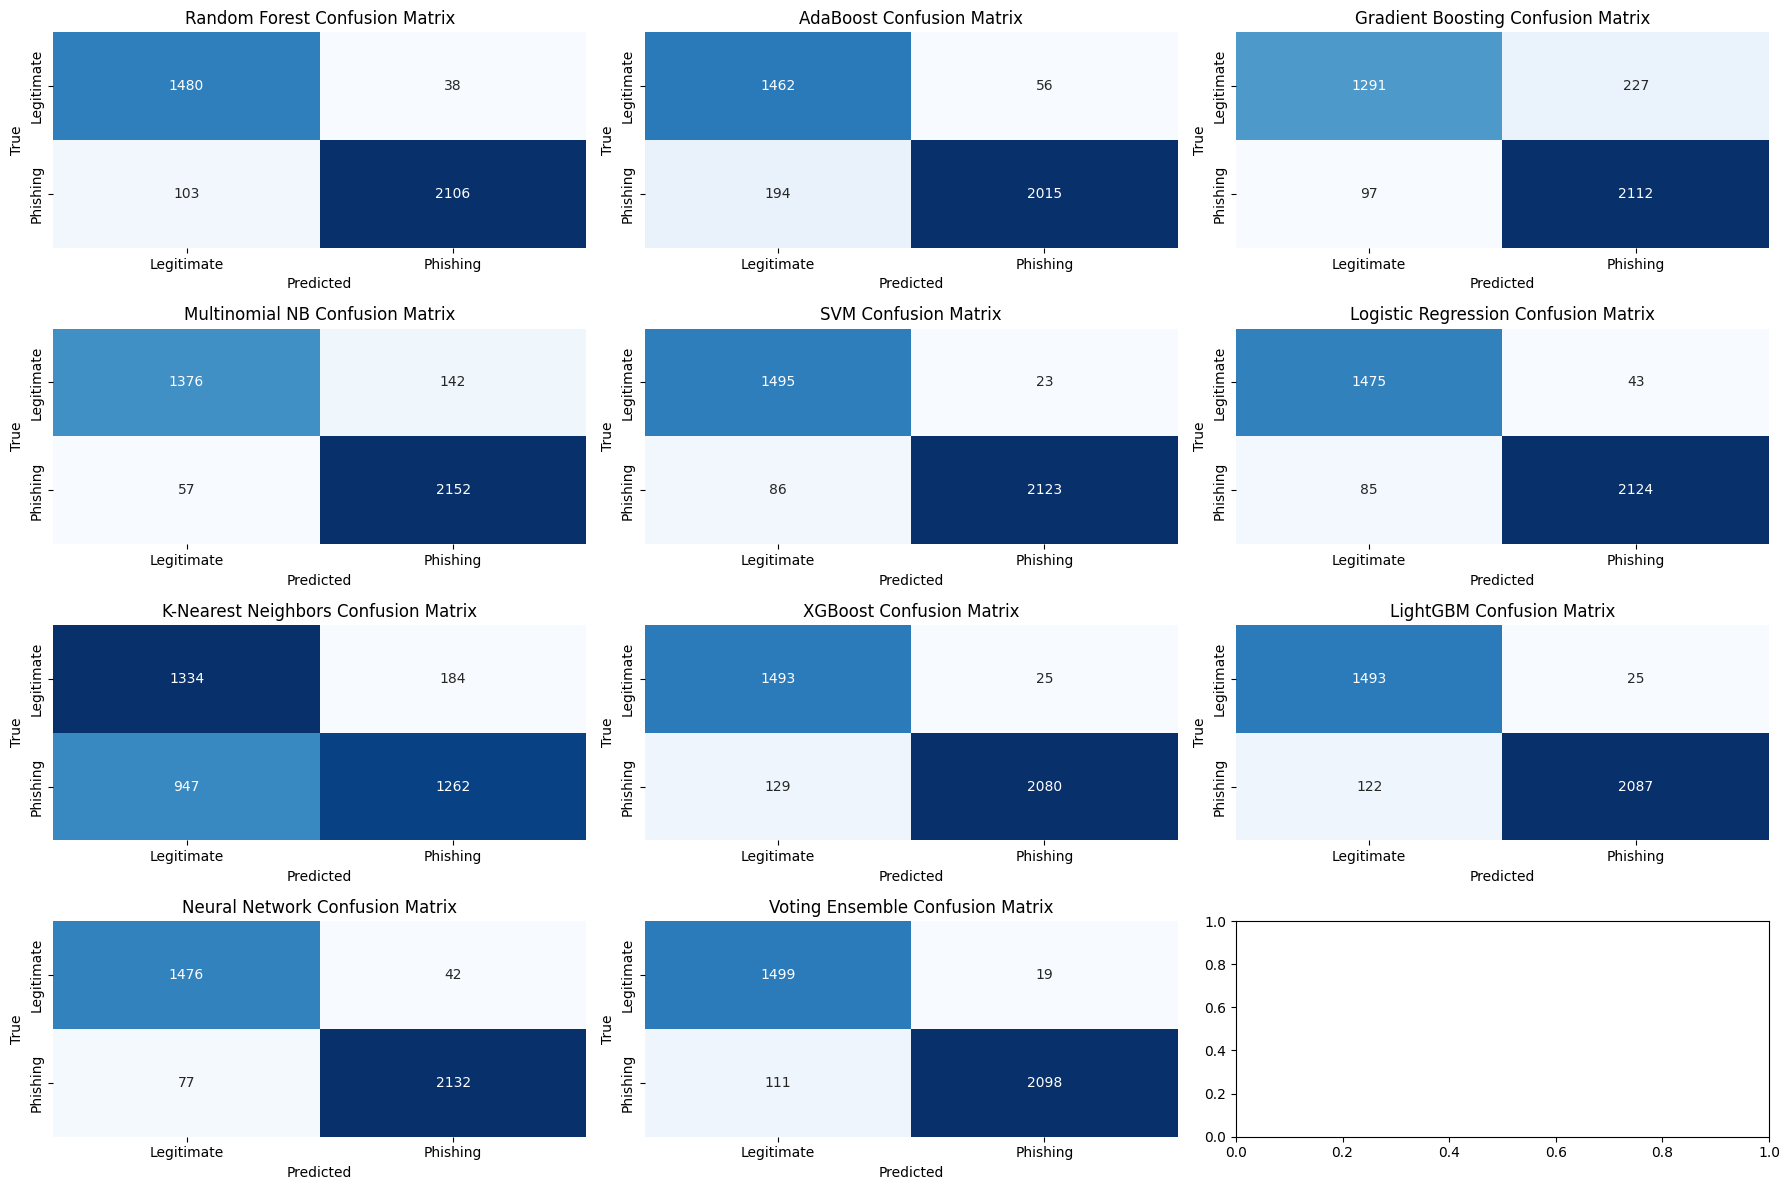

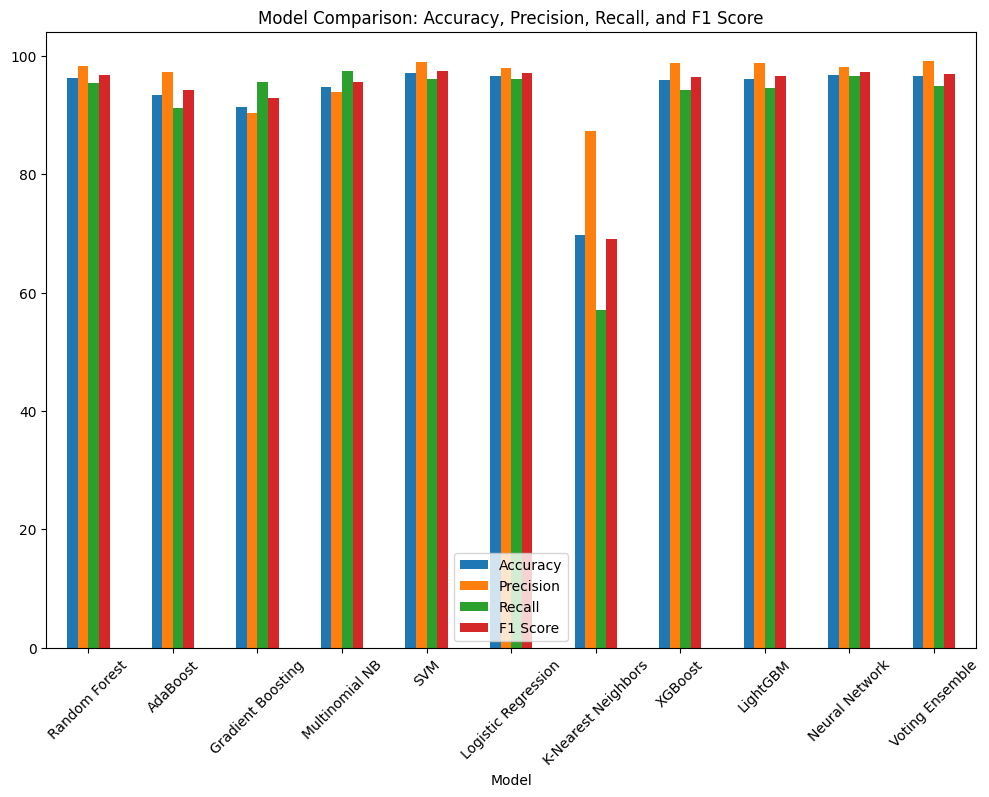

                  Model   Accuracy  Precision     Recall   F1 Score
0         Random Forest  96.216796  98.227612  95.337257  96.760855
1              AdaBoost  93.292192  97.295992  91.217746  94.158879
2     Gradient Boosting  91.306681  90.294998  95.608873  92.875989
3        Multinomial NB  94.660585  93.809939  97.419647  95.580724
4                   SVM  97.075396  98.928239  96.106836  97.497130
5   Logistic Regression  96.565602  98.015690  96.152105  97.074954
6   K-Nearest Neighbors  69.653877  87.275242  57.129923  69.056088
7               XGBoost  95.867990  98.812352  94.160254  96.430227
8              LightGBM  96.055809  98.816288  94.477139  96.598010
9        Neural Network  96.807083  98.068077  96.514260  97.284965
10      Voting Ensemble  96.511940  99.102504  94.975102  96.994914


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stop_words

def clean_text(text):
    text = re.sub(r'\W', ' ', text)  
    text = text.lower()  
    text = text.split()  
    text = [word for word in text if word not in stop_words]  
    return ' '.join(text)

# Load and prepare data
# data = pd.read_csv('your_email_data.csv')  # Uncomment to load actual data
# Example data
#data  = pd.read_csv("C:\\Users\\sobha\\OneDrive\\Desktop\\CODING\\PE1\\updated_file.csv")
data = pd.read_csv("C:\\Users\\sobha\\Downloads\\Phishing_Email.csv\\Phishing_Email.csv")
data = data.dropna(subset=['Email Text'])

plot = sns.countplot(x='Email Type', data=data)

# Add bar labels in a concise manner
plot.bar_label(plot.containers[0], fmt='%d')

# Add title and display the plot
plt.title('Email Type Distribution')
plt.show()

cleaned_emails = data['Email Text'].apply(clean_text).tolist()
data['Email Type'] = LabelEncoder().fit_transform(data['Email Type'])
X_train, X_test, y_train, y_test = train_test_split(data['Email Text'], data['Email Type'], test_size=0.2, random_state=42)



# Define models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Multinomial NB': MultinomialNB(),
    'SVM': SVC(kernel='linear', random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
}

# Voting Ensemble
models['Voting Ensemble'] = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting='hard'
)

# Initialize result storage
results = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}

# Plotting configuration
fig, axes = plt.subplots(len(models) // 3 + 1, 3, figsize=(18, len(models) // 3 * 4))
axes = axes.flatten()

# Evaluate each model
for idx, (name, model) in enumerate(models.items()):
    # Setup pipeline and train model
    pipeline = Pipeline([('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Store metrics
    results['Model'].append(name)
    results['Accuracy'].append(accuracy_score(y_test, y_pred)*100)
    results['Precision'].append(precision_score(y_test, y_pred)*100)
    results['Recall'].append(recall_score(y_test, y_pred)*100)
    results['F1 Score'].append(f1_score(y_test, y_pred)*100)
    
    # Plot confusion matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'], ax=axes[idx])
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()

# Display performance comparison
results_df = pd.DataFrame(results)
results_df.plot(kind='bar', x='Model', y=['Accuracy', 'Precision', 'Recall', 'F1 Score'], figsize=(12, 8))
plt.title('Model Comparison: Accuracy, Precision, Recall, and F1 Score')
plt.xticks(rotation=45)
plt.show()

# Print model scores
print(results_df)
